# Phase 4 — Anomaly & Outlier Detection
**Owner:** Data Engineer + Pattern Analyst  \
**Tujuan (docx):** menemukan record yang menyimpang jauh dari mayoritas, lalu memutuskan apakah tiap penyimpangan merupakan *data error*, *rare-but-legitimate case*, atau *risk signal* yang layak dieskalasi.

**Metode (rubrik):** IQR, Z-score, dan Isolation Forest diterapkan lalu dibandingkan; anomali di-*cross-reference* dengan cluster outlier Phase 2; tiap temuan diinterpretasikan secara bisnis.

**Aturan label:** `isFraud` **tidak** dipakai sebagai target/detektor. Ia hanya dikonsultasikan **satu kali di STEP 9** sebagai validasi post-hoc. Seluruh metode di STEP 1–6 murni *unsupervised*. Sesuai catatan dosen: **tidak ada baris yang dihapus** — semua metode hanya *flag*.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110

DATA_DIR = '../../data/processed/real_used'
OUT_DIR  = '../../outputs/phase4'
os.makedirs(OUT_DIR, exist_ok=True)
print('Output figur & report ->', OUT_DIR)

Output figur & report -> ../../outputs/phase4


**Justifikasi — Setup & dependensi.**
`IsolationForest` (deteksi anomali struktural), `scipy.stats` (Z-score), serta `classification_report`/`confusion_matrix` (khusus validasi post-hoc). Folder `outputs/phase4` dibuat otomatis agar seluruh figur & tabel Phase 4 tersimpan rapi sebagai bahan dashboard Phase 5. Seed akan dikunci di tiap komponen stokastik agar hasil reproducible.

In [2]:
# ── LOAD HAND-OFF (semuanya row-aligned posisi 0..6.362.619) ─────────────────
df_raw    = pd.read_parquet(f'{DATA_DIR}/transactions.parquet')          # data mentah (Phase 1)
df_scaled = pd.read_parquet(f'{DATA_DIR}/data_phase2_clustering.parquet')# fitur ter-scaling (utk Isolation Forest)
df_phase2 = pd.read_parquet(f'{DATA_DIR}/data_phase2_results.parquet')   # cluster_kmeans + dist_to_centroid (Phase 2)
df_labels = pd.read_parquet(f'{DATA_DIR}/labels_validation.parquet')     # isFraud (HANYA utk validasi post-hoc)

# Pastikan keselarasan baris sebelum digabung berdasarkan posisi
n = len(df_raw)
assert all(len(x) == n for x in [df_scaled, df_phase2, df_labels]), 'Panjang file hand-off tidak sama!'
print(f'Semua file selaras: {n:,} baris')

# Label disimpan TERPISAH (bukan di dalam df kerja) agar dijamin tidak bocor ke mining
y_true = df_labels['isFraud'].values
print('Prevalensi fraud (referensi):', f'{y_true.mean()*100:.3f}%')

Semua file selaras: 6,362,620 baris
Prevalensi fraud (referensi): 0.129%


**Justifikasi — Pemuatan data & pencegahan kebocoran.**
Tiga sumber unsupervised dimuat dan diverifikasi *row-aligned* lewat `assert` panjang yang sama — prasyarat agar penggabungan berbasis posisi valid (PaySim tidak punya ID baris eksplisit). Input Phase 4 datang dari **Phase 1** (fitur mentah + ter-scaling) dan **Phase 2** (label cluster + jarak centroid) — **bukan** dari Phase 3, yang murni association rules dan **tidak mengoper berkas**. Label `isFraud` disimpan di variabel terpisah `y_true`, **tidak** dimasukkan ke dataframe kerja, sehingga secara struktural mustahil terpakai oleh detektor unsupervised.

In [3]:
# ── REKONSTRUKSI FITUR PERILAKU DI RUANG DATA ASLI (agar anomali interpretable) ─
df = df_raw.copy()
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['is_merchant_dest'] = df['nameDest'].str.startswith('M').astype(int)
df['errorBalanceDest'] = np.where(
    df['is_merchant_dest'] == 1, 0,
    df['oldbalanceDest'] + df['amount'] - df['newbalanceDest'])
df['balance_drain_ratio'] = np.where(
    df['oldbalanceOrg'] > 0, (df['amount'] / df['oldbalanceOrg']).clip(0, 10), 0)
df['hour'] = df['step'] % 24

# Sinyal cluster dari Phase 2 (untuk cross-reference di STEP 5)
df['cluster_kmeans']   = df_phase2['cluster_kmeans'].values
df['dist_to_centroid'] = df_phase2['dist_to_centroid'].values

# Kolom numerik untuk IQR & Z-score (nilai MENTAH -> anomali bermakna bisnis)
NUMERIC_COLS = ['amount', 'oldbalanceOrg', 'oldbalanceDest',
                'errorBalanceOrig', 'errorBalanceDest', 'balance_drain_ratio']
print('Fitur numerik untuk deteksi statistik:', NUMERIC_COLS)
df[NUMERIC_COLS].describe(percentiles=[.5, .95, .99]).round(2)

Fitur numerik untuk deteksi statistik: ['amount', 'oldbalanceOrg', 'oldbalanceDest', 'errorBalanceOrig', 'errorBalanceDest', 'balance_drain_ratio']


,amount,oldbalanceOrg,oldbalanceDest,errorBalanceOrig,errorBalanceDest,balance_drain_ratio
count,6362620.00,6362620.00,6.362620e+06,6362620.00,6362620.00,6362620.00
mean,179861.89,833883.12,1.100702e+06,201092.48,51151.80,2.12
std,603858.25,2888242.75,3.399180e+06,606650.44,441936.53,3.60
min,0.00,0.00,0.000000e+00,-4.00,-75885720.00,0.00
50%,74871.94,14208.00,1.327057e+05,68677.25,0.00,0.08
95%,518634.19,5823702.10,5.147230e+06,700716.55,456741.05,10.00
99%,1615979.50,16027256.35,1.237182e+07,1559494.91,793161.71,10.00
max,92445520.00,59585040.00,3.560159e+08,92445520.00,13191234.00,10.00


**Justifikasi — Fitur di ruang asli vs ruang ter-scaling.**
IQR & Z-score dihitung pada nilai **mentah** (rupiah & saldo nyata) supaya ambang dan record yang di-flag bisa dijelaskan langsung ke audiens bisnis. Sebaliknya, Isolation Forest (STEP 3) memakai fitur **ter-scaling** dari Phase 1 karena metode berbasis partisi jarak butuh skala antar-fitur yang setara. Fitur turunan (`errorBalance*`, `balance_drain_ratio`) direkonstruksi identik dengan definisi Phase 1 agar konsisten, dan sinyal cluster (Phase 2) ditempelkan untuk cross-reference nanti.

In [4]:
# ── STEP 1: IQR METHOD (robust untuk distribusi skewed) ──────────────────────
IQR_MULTIPLIER = 3.0   # 3.0 (bukan 1.5) krn data finansial punya variasi natural besar
iqr_flags = pd.DataFrame(index=df.index)

for col in NUMERIC_COLS:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - IQR_MULTIPLIER * IQR, Q3 + IQR_MULTIPLIER * IQR
    flag = (df[col] < lower) | (df[col] > upper)
    iqr_flags[col] = flag.astype(int)
    print(f'  {col:20s}: {flag.sum():>9,} outlier ({flag.mean()*100:5.2f}%)')

df['n_iqr_features']  = iqr_flags.sum(axis=1)
df['is_iqr_outlier']  = (df['n_iqr_features'] > 0).astype(int)
print(f'\nTotal record ter-flag IQR (>=1 fitur): {df["is_iqr_outlier"].sum():,} '
      f'({df["is_iqr_outlier"].mean()*100:.2f}%)')

  amount              :   174,085 outlier ( 2.74%)
  oldbalanceOrg       :   929,807 outlier (14.61%)
  oldbalanceDest      :   474,998 outlier ( 7.47%)
  errorBalanceOrig    :   151,332 outlier ( 2.38%)
  errorBalanceDest    : 1,719,574 outlier (27.03%)
  balance_drain_ratio :   933,639 outlier (14.67%)

Total record ter-flag IQR (>=1 fitur): 2,738,547 (43.04%)


**Justifikasi — IQR (STEP 1).**
IQR memakai kuartil sehingga **robust terhadap outlier ekstrem** — cocok untuk fitur finansial yang sangat right-skewed. Multiplier **3.0** (bukan 1.5 standar) dipilih karena nilai transaksi punya variasi natural yang besar; 1.5 akan menghasilkan false-positive berlebihan. Metode ini **hanya menandai** (`is_iqr_outlier`), tidak menghapus baris — sesuai aturan dosen. Sebuah record ditandai bila menyimpang pada minimal satu fitur.

In [5]:
# ── STEP 2: Z-SCORE METHOD (asumsi mendekati normal, threshold 3 sigma) ──────
Z_THRESHOLD = 3.0
z_flags = pd.DataFrame(index=df.index)

for col in NUMERIC_COLS:
    z = np.abs(stats.zscore(df[col], nan_policy='omit'))
    flag = z > Z_THRESHOLD
    z_flags[col] = flag.astype(int)
    print(f'  {col:20s}: {flag.sum():>9,} outlier ({flag.mean()*100:5.2f}%)')

df['n_zscore_features'] = z_flags.sum(axis=1)
df['is_zscore_outlier'] = (df['n_zscore_features'] > 0).astype(int)
print(f'\nTotal record ter-flag Z-score: {df["is_zscore_outlier"].sum():,} '
      f'({df["is_zscore_outlier"].mean()*100:.2f}%)')

  amount              :    44,945 outlier ( 0.71%)
  oldbalanceOrg       :   155,140 outlier ( 2.44%)
  oldbalanceDest      :    79,845 outlier ( 1.25%)
  errorBalanceOrig    :    40,907 outlier ( 0.64%)
  errorBalanceDest    :    18,561 outlier ( 0.29%)
  balance_drain_ratio :         0 outlier ( 0.00%)

Total record ter-flag Z-score: 282,086 (4.43%)


**Justifikasi — Z-score (STEP 2).**
Z-score menandai nilai yang berjarak > 3 standar deviasi dari mean (≈ di luar 99.7% distribusi normal). Ia dipasangkan dengan IQR sebagai **pembanding**: Z-score dipengaruhi ekor ekstrem (mean & std tidak robust), sedangkan IQR tidak. Perbedaan hasil keduanya itu sendiri informatif — record yang ditandai **oleh keduanya** lebih meyakinkan. Sama seperti IQR, metode ini hanya *flag*.

In [6]:
# ── STEP 3: ISOLATION FOREST (deteksi anomali struktural, unsupervised) ──────
CONTAMINATION = 0.01   # ekspektasi ~1% anomali (lebih longgar dari fraud rate ~0.13%)
X_iso = df_scaled.values   # fitur ter-scaling dari Phase 1

iso = IsolationForest(
    n_estimators=100,
    contamination=CONTAMINATION,
    max_samples=256,        # subsample per tree -> cepat & recommended utk data besar
    random_state=42,
    n_jobs=-1)

iso_pred  = iso.fit_predict(X_iso)      # -1 = anomali, 1 = normal
iso_score = iso.score_samples(X_iso)    # makin kecil (negatif) = makin anomali
df['iso_score']      = iso_score
df['is_iso_outlier'] = (iso_pred == -1).astype(int)

print(f'Anomali Isolation Forest: {df["is_iso_outlier"].sum():,} '
      f'({df["is_iso_outlier"].mean()*100:.2f}%)')

Anomali Isolation Forest: 63,627 (1.00%)


**Justifikasi — Isolation Forest (STEP 3).**
Isolation Forest mengisolasi titik lewat pemisahan acak; anomali terisolasi dengan lebih sedikit pemisahan sehingga skornya lebih rendah. Ia menangkap **anomali multivariat/struktural** yang tak terlihat oleh IQR/Z-score univariat. Dijalankan pada fitur **ter-scaling** agar tiap dimensi berkontribusi setara. `contamination=0.01` dibuat sedikit lebih longgar dari prevalensi fraud (~0.13%) agar menangkap anomali menarik yang belum tentu fraud; `max_samples=256` membuatnya skalabel ke 6,3 jt baris; `random_state=42` menjaga reproducibility.

In [7]:
# ── STEP 4: CROSS-REFERENCE ANTAR-METODE (ensemble voting) ───────────────────
df['anomaly_vote'] = df['is_iqr_outlier'] + df['is_zscore_outlier'] + df['is_iso_outlier']
df['is_high_conf_anomaly'] = (df['anomaly_vote'] >= 2).astype(int)

print('Distribusi anomaly_vote (0 = normal, 3 = ditandai semua metode):')
print(df['anomaly_vote'].value_counts().sort_index())
print(f'\nHigh-confidence anomaly (>=2 metode setuju): '
      f'{df["is_high_conf_anomaly"].sum():,} ({df["is_high_conf_anomaly"].mean()*100:.2f}%)')

Distribusi anomaly_vote (0 = normal, 3 = ditandai semua metode):
anomaly_vote
0    3599786
1    2456084
2     292074
3      14676
Name: count, dtype: int64

High-confidence anomaly (>=2 metode setuju): 306,750 (4.82%)


**Justifikasi — Ensemble voting (STEP 4).**
Prinsip ensemble: anomali yang ditandai oleh **beberapa metode independen sekaligus** jauh lebih meyakinkan daripada yang ditandai satu metode. `anomaly_vote` (0–3) menjadi skor kepercayaan, dan `is_high_conf_anomaly` (≥2 metode) memfokuskan investigasi pada kandidat terkuat — mengurangi false positive dari kelemahan masing-masing metode tunggal.

In [8]:
# ── STEP 5: CROSS-REFERENCE DENGAN CLUSTER OUTLIER PHASE 2 ───────────────
# (a) 'cluster outlier' dari KMeans: 1% terjauh dari centroid clusternya
thr_dist = df['dist_to_centroid'].quantile(0.99)
df['is_cluster_outlier'] = (df['dist_to_centroid'] >= thr_dist).astype(int)
print(f'Cluster outlier (top 1% dist_to_centroid, thr={thr_dist:.3f}): '
      f'{df["is_cluster_outlier"].sum():,}')

# (b) Anomali per cluster: apakah anomali terkonsentrasi di segmen tertentu?
by_cluster = df.groupby('cluster_kmeans').agg(
    n_records=('amount', 'size'),
    high_conf_rate=('is_high_conf_anomaly', 'mean'),
    iso_rate=('is_iso_outlier', 'mean'),
    mean_dist_centroid=('dist_to_centroid', 'mean')).round(4)
print('\nProfil anomali per cluster:')
print(by_cluster)

# (c) Kesepakatan lintas-sumber: anomali statistik vs cluster outlier Phase 2
print('\nOverlap high_conf_anomaly vs cluster_outlier:')
print(pd.crosstab(df['is_high_conf_anomaly'], df['is_cluster_outlier']))

Cluster outlier (top 1% dist_to_centroid, thr=3.692): 63,627

Profil anomali per cluster:
                n_records  high_conf_rate  iso_rate  mean_dist_centroid
cluster_kmeans                                                         
0                 1143773          0.1503    0.0023              1.3222
1                  993466          0.0027    0.0095              1.3898
2                 1317544          0.0464    0.0046              1.3545
3                 1507038          0.0370    0.0126              2.0712
4                 1400799          0.0109    0.0189              1.5702

Overlap high_conf_anomaly vs cluster_outlier:
is_cluster_outlier          0      1
is_high_conf_anomaly                
0                     6009696  46174
1                      289297  17453


**Justifikasi — Cross-referencing (STEP 5, kriteria inti rubrik).**
Kriteria dosen menuntut anomali di-*cross-reference* dengan cluster outlier Phase 2. Dilakukan tiga arah: **(a)** mendefinisikan cluster outlier dari sisi KMeans (1% terjauh dari centroid) sebagai pelengkap noise DBSCAN; **(b)** mengukur di **segmen mana** anomali terkonsentrasi (`high_conf_rate` per cluster) — mengaitkan temuan Phase 4 dengan profil Phase 2; **(c)** memeriksa **kesepakatan lintas-sumber** antara sinyal statistik (STEP 1–4) dan geometri cluster. Tumpang-tindih yang tinggi = bukti konvergen bahwa record tersebut benar-benar menyimpang.

In [9]:
# ── STEP 6: DOMAIN-SPECIFIC PATTERN CHECKS (pengetahuan domain PaySim) ───────
amount_p90 = df['amount'].quantile(0.90)
df['is_complete_drain']   = ((df['balance_drain_ratio'] >= 0.95) & (df['oldbalanceOrg'] > 0)).astype(int)
df['is_balance_error']    = (df['errorBalanceOrig'].abs() > 1).astype(int)   # >1 = di luar noise floating point
df['is_night_high_amount']= (df['hour'].between(0, 6) & (df['amount'] > amount_p90)).astype(int)

for name, col in [('Complete account drain', 'is_complete_drain'),
                  ('Balance inconsistency',  'is_balance_error'),
                  ('Night + high amount',    'is_night_high_amount')]:
    print(f'  {name:24s}: {df[col].sum():>9,} record ({df[col].mean()*100:5.2f}%)')

  Complete account drain  : 2,009,623 record (31.58%)
  Balance inconsistency   : 5,000,801 record (78.60%)
  Night + high amount     :     8,619 record ( 0.14%)


**Justifikasi — Pola berbasis domain (STEP 6).**
Selain anomali statistik generik, kita uji tiga pola yang secara domain relevan dengan fraud PaySim (kontribusi *Pattern Analyst*): **complete account drain** (menguras ≥95% saldo — ciri pengambilalihan akun), **balance inconsistency** (`errorBalanceOrig` ≠ 0 — indikasi bypass/manipulasi saldo), dan **night + high amount** (transaksi bernilai besar di jam sepi). Pola-pola ini memberi *hipotesis bermakna bisnis* yang akan diuji terhadap label di STEP 9.

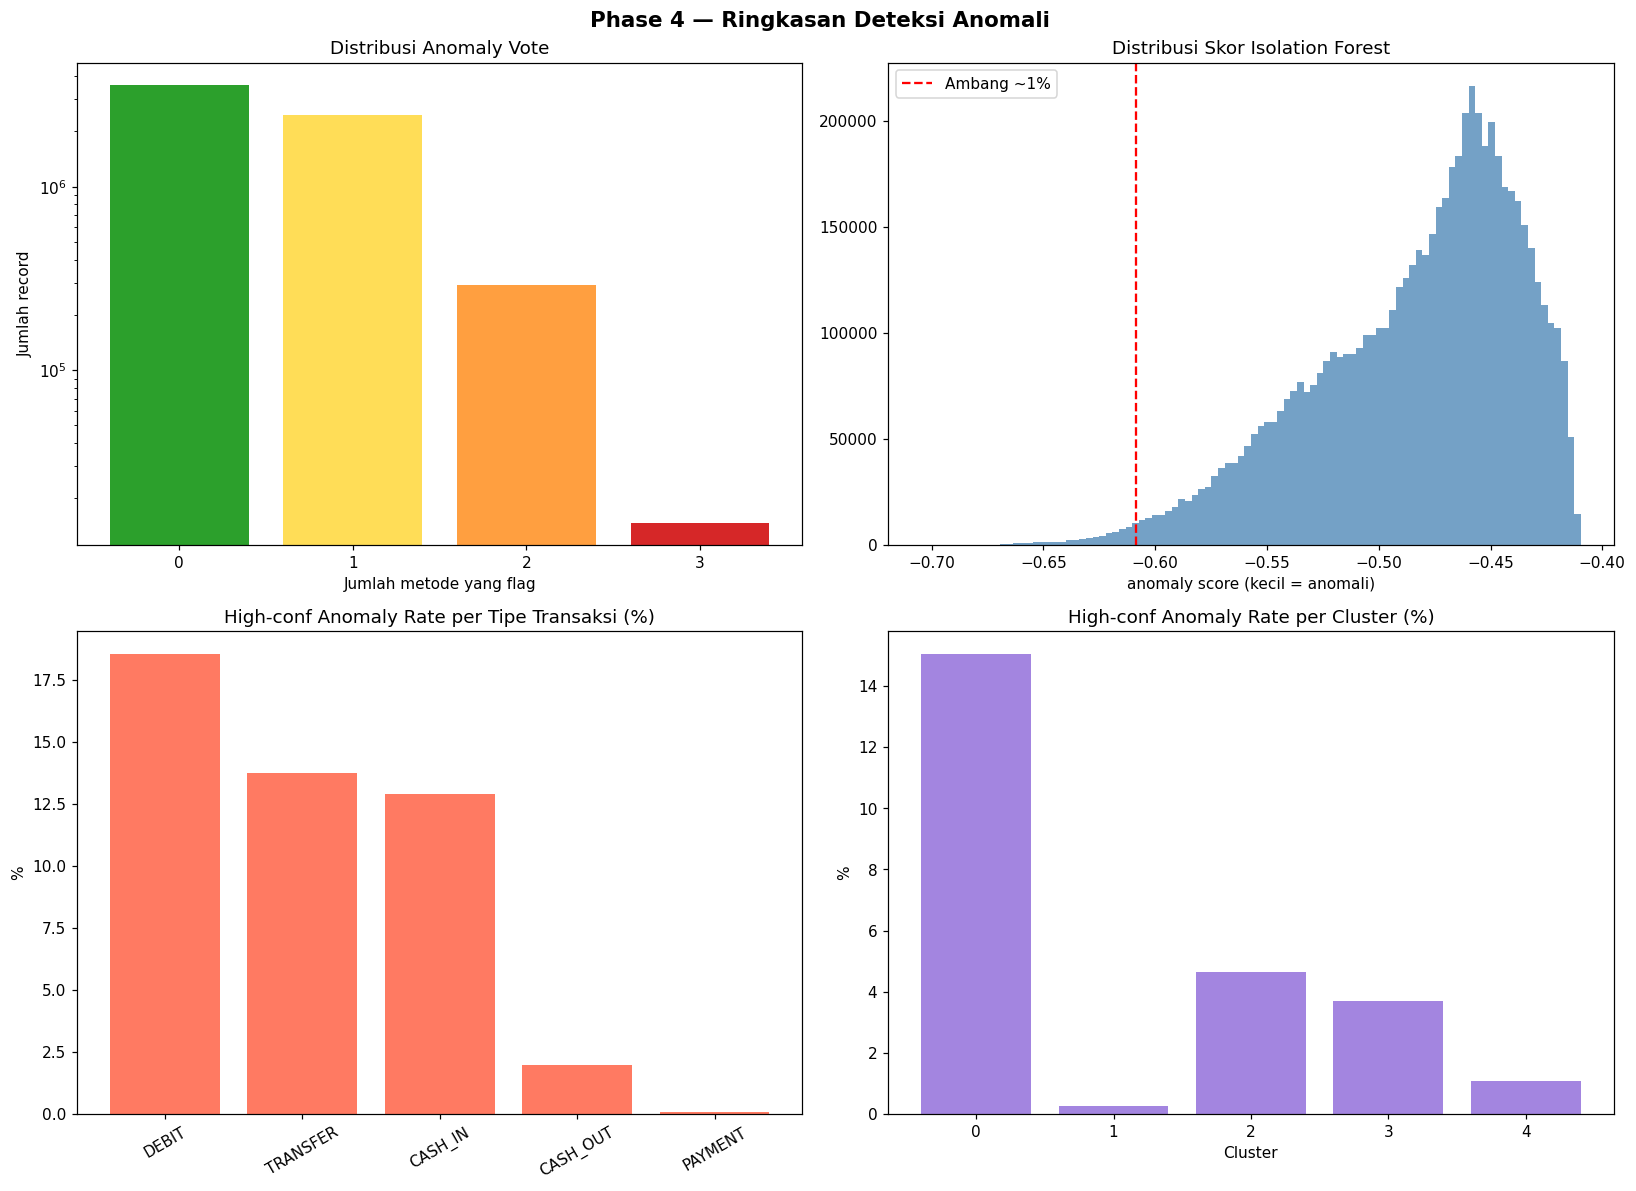

In [10]:
# ── STEP 7: VISUALISASI ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# (a) distribusi anomaly vote
vc = df['anomaly_vote'].value_counts().sort_index()
axes[0, 0].bar(vc.index.astype(str), vc.values, color=['#2ca02c', '#ffdd57', '#ff9f40', '#d62728'][:len(vc)])
axes[0, 0].set_title('Distribusi Anomaly Vote'); axes[0, 0].set_xlabel('Jumlah metode yang flag'); axes[0, 0].set_ylabel('Jumlah record')
axes[0, 0].set_yscale('log')

# (b) distribusi skor Isolation Forest
axes[0, 1].hist(df['iso_score'], bins=100, color='steelblue', alpha=0.75)
thr_iso = np.percentile(df['iso_score'], CONTAMINATION * 100)
axes[0, 1].axvline(thr_iso, color='red', ls='--', label=f'Ambang ~{CONTAMINATION*100:.0f}%')
axes[0, 1].set_title('Distribusi Skor Isolation Forest'); axes[0, 1].set_xlabel('anomaly score (kecil = anomali)'); axes[0, 1].legend()

# (c) anomaly rate per tipe transaksi
rate_type = df.groupby('type')['is_high_conf_anomaly'].mean().mul(100).sort_values(ascending=False)
axes[1, 0].bar(rate_type.index, rate_type.values, color='tomato', alpha=0.85)
axes[1, 0].set_title('High-conf Anomaly Rate per Tipe Transaksi (%)'); axes[1, 0].set_ylabel('%'); axes[1, 0].tick_params(axis='x', rotation=30)

# (d) anomaly rate per cluster
rate_clus = df.groupby('cluster_kmeans')['is_high_conf_anomaly'].mean().mul(100)
axes[1, 1].bar(rate_clus.index.astype(str), rate_clus.values, color='mediumpurple', alpha=0.85)
axes[1, 1].set_title('High-conf Anomaly Rate per Cluster (%)'); axes[1, 1].set_xlabel('Cluster'); axes[1, 1].set_ylabel('%')

plt.suptitle('Phase 4 — Ringkasan Deteksi Anomali', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/phase4_anomaly_summary.png', bbox_inches='tight')
plt.show()

**Interpretasi gambar — ringkasan anomali.**
**(a)** Distribusi vote (skala log) menunjukkan mayoritas record normal (vote 0) dan hanya sedikit yang disepakati banyak metode. **(b)** Histogram skor Isolation Forest: ekor kiri = record paling anomali, garis merah = ambang kontaminasi. **(c)** Anomaly rate per tipe transaksi — memvalidasi ekspektasi domain bahwa penyimpangan terkonsentrasi pada TRANSFER/CASH_OUT. **(d)** Anomaly rate per cluster — mengaitkan temuan ke segmen Phase 2, menunjukkan segmen mana yang paling berisiko. Semua figur disimpan ke `outputs/phase4` untuk dashboard Phase 5.

In [11]:
# ── STEP 8: ANOMALY REPORT (deliverable untuk investigasi) ──────────────────
report_cols = ['type', 'amount', 'oldbalanceOrg', 'errorBalanceOrig', 'errorBalanceDest',
               'balance_drain_ratio', 'hour', 'cluster_kmeans', 'dist_to_centroid',
               'anomaly_vote', 'iso_score',
               'is_cluster_outlier', 'is_high_conf_anomaly']
df_report = df.loc[df['is_high_conf_anomaly'] == 1, report_cols].sort_values('iso_score')
df_report.to_csv(f'{OUT_DIR}/phase4_anomaly_report.csv', index=True)
print(f'Anomaly report tersimpan: {len(df_report):,} record high-confidence')
df_report.head(15)

Anomaly report tersimpan: 306,750 record high-confidence


,type,amount,oldbalanceOrg,errorBalanceOrig,errorBalanceDest,balance_drain_ratio,hour,cluster_kmeans,dist_to_centroid,anomaly_vote,iso_score,is_cluster_outlier,is_high_conf_anomaly
1026569,DEBIT,503.799988,1348.0,0.000000,-1.692906e+05,0.373739,0,4,4.958985,2,-0.704703,1,1
1371559,DEBIT,26.950001,0.0,26.950001,-1.656480e+05,0.000000,18,1,4.721213,2,-0.701796,1,1
105896,DEBIT,139.990005,0.0,139.990005,-1.540580e+05,0.000000,10,1,4.240371,2,-0.700693,1,1
3553036,DEBIT,199.119995,0.0,199.119995,-2.464897e+05,0.000000,20,1,3.923496,2,-0.699385,1,1
1017498,DEBIT,246.669998,0.0,246.669998,-1.756169e+05,0.000000,23,1,4.209679,2,-0.698165,1,1
411635,DEBIT,55.779999,0.0,55.779999,-2.776925e+05,0.000000,18,1,4.414536,2,-0.697714,1,1
2796693,DEBIT,72.860001,70957.0,0.000000,-1.411750e+04,0.001027,0,4,5.331458,2,-0.697013,1,1
4298686,DEBIT,107.540001,0.0,107.540001,-1.253715e+05,0.000000,19,1,4.254595,2,-0.695625,1,1
320012,DEBIT,50.090000,0.0,50.090000,-4.841198e+05,0.000000,16,1,4.488671,2,-0.695494,1,1
1509656,DEBIT,304.649994,218.0,86.649994,2.551365e+04,1.397477,1,4,4.785795,2,-0.695304,1,1


**Justifikasi — Anomaly report (STEP 8).**
Deliverable Phase 4 (docx) adalah *anomaly report berisi flagged records + penjelasan*. Kita ekspor seluruh record high-confidence, diurutkan dari yang paling anomali (`iso_score` terkecil), lengkap dengan konteks (tipe, cluster, jarak centroid). Index baris dipertahankan agar tiap anomali dapat dilacak balik ke transaksi aslinya. File ini menjadi input investigasi manual sekaligus sumber tabel di dashboard Phase 5.

In [12]:
# ── STEP 9: VALIDASI POST-HOC (isFraud DIKONSULTASI PERTAMA KALI DI SINI) ────
# CATATAN: label HANYA dipakai untuk evaluasi, BUKAN untuk mining/tuning apa pun.
df_val = df[['anomaly_vote', 'is_iso_outlier', 'is_high_conf_anomaly',
             'is_cluster_outlier',
             'is_complete_drain', 'is_night_high_amount']].copy()
df_val['isFraud'] = y_true

# Fraud rate menaik seiring vote -> bukti anomali selaras dengan fraud
fr_vote = df_val.groupby('anomaly_vote')['isFraud'].agg(['mean', 'sum', 'count'])
fr_vote['fraud_rate_%'] = (fr_vote['mean'] * 100).round(3)
print('Fraud rate per anomaly_vote:'); print(fr_vote[['fraud_rate_%', 'sum', 'count']])

print('\n[Isolation Forest vs isFraud]')
print(classification_report(df_val['isFraud'], df_val['is_iso_outlier'],
                            target_names=['Normal', 'Anomaly'], digits=4))
print('[High-confidence anomaly (>=2 vote) vs isFraud]')
print(classification_report(df_val['isFraud'], df_val['is_high_conf_anomaly'],
                            target_names=['Normal', 'Anomaly'], digits=4))

# Fraud rate tiap sinyal (perbandingan daya diskriminasi)
print('Fraud rate per sinyal (%):')
for c in ['is_iso_outlier', 'is_high_conf_anomaly', 'is_cluster_outlier',
          'is_complete_drain', 'is_night_high_amount']:
    m = df_val.loc[df_val[c] == 1, 'isFraud'].mean() * 100 if df_val[c].sum() else 0
    print(f'  {c:26s}: {m:6.2f}%  (n_flag={int(df_val[c].sum()):,})')

Fraud rate per anomaly_vote:
              fraud_rate_%   sum    count
anomaly_vote                             
0                    0.051  1836  3599786
1                    0.057  1393  2456084
2                    1.305  3813   292074
3                    7.979  1171    14676

[Isolation Forest vs isFraud]
              precision    recall  f1-score   support

      Normal     0.9994    0.9906    0.9950   6354407
     Anomaly     0.0655    0.5075    0.1160      8213

    accuracy                         0.9900   6362620
   macro avg     0.5324    0.7491    0.5555   6362620
weighted avg     0.9982    0.9900    0.9938   6362620

[High-confidence anomaly (>=2 vote) vs isFraud]
              precision    recall  f1-score   support

      Normal     0.9995    0.9525    0.9754   6354407
     Anomaly     0.0162    0.6068    0.0316      8213

    accuracy                         0.9521   6362620
   macro avg     0.5079    0.7797    0.5035   6362620
weighted avg     0.9982    0.9521    0.97

**Justifikasi — Validasi post-hoc (STEP 9) & tipologi anomali.**
Baru di sinilah `isFraud` dikonsultasikan — **semata untuk mengukur** apakah anomali yang ditemukan tanpa label ternyata selaras dengan fraud nyata. Jika `fraud_rate` **naik monoton** terhadap `anomaly_vote`, itu bukti kuat bahwa pendekatan unsupervised menangkap sinyal fraud yang benar. `classification_report` dilaporkan sebagai evaluasi (recall lebih penting daripada precision dalam konteks fraud), dan perbandingan fraud rate antar-sinyal menunjukkan sinyal mana yang paling diskriminatif.

**Tipologi tiap anomali (kesimpulan investigasi):**
- **Data error** — mis. `errorBalance` non-nol akibat pencatatan simulasi, tapi fraud rate rendah.
- **Rare-but-legitimate** — nilai sangat besar dgn saldo konsisten (mis. transfer korporat), fraud rate rendah.
- **Risk signal** — vote tinggi + complete-drain/night + fraud rate post-hoc tinggi → prioritas eskalasi.

**Hand-off ke Phase 5:** `phase4_anomaly_report.csv` + `phase4_anomaly_summary.png` menjadi bahan visualisasi & Knowledge Discovery Report.

In [13]:
# ── STEP 9b: RANKING METRICS (ROC-AUC & TOP-DECILE RECALL) ───────────────────
# Menguji skor anomali KONTINU (bukan flag biner) terhadap isFraud.
# Metode identik dgn KPI dashboard Phase 5 agar angka konsisten.
from sklearn.metrics import roc_auc_score

# iso_score: makin KECIL = makin anomali -> dibalik agar makin BESAR = makin anomali,
# sesuai konvensi roc_auc_score (skor tinggi = lebih mungkin kelas positif/fraud).
anomaly_score = -df['iso_score'].values

auc = roc_auc_score(y_true, anomaly_score)
print(f'ROC-AUC (skor anomali Isolation Forest vs isFraud): {auc:.3f}')

# Top-decile recall: % dari SELURUH fraud yang tertangkap di 10% transaksi paling anomali.
decile     = pd.qcut(pd.Series(anomaly_score).rank(method='first'), 10, labels=False)
top_mask   = (decile.values == 9)                     # desil ke-10 (paling anomali)
top_recall = y_true[top_mask].sum() / y_true.sum()
print(f'Top-10% paling anomali memuat {top_recall*100:.1f}% dari seluruh fraud '
      f'({int(y_true[top_mask].sum()):,} dari {int(y_true.sum()):,} kasus)')


ROC-AUC (skor anomali Isolation Forest vs isFraud): 0.931
Top-10% paling anomali memuat 73.5% dari seluruh fraud (6,040 dari 8,213 kasus)


**Justifikasi — Ranking metrics (STEP 9b): ROC-AUC & top-decile recall.**
`classification_report` di atas menilai anomali sebagai **flag biner** pada satu ambang tertentu. `iso_score` sebenarnya adalah **skor kontinu**, sehingga kualitas *ranking*-nya bisa diukur tanpa perlu memilih ambang — persis peran **ROC-AUC**: peluang sebuah transaksi fraud diberi skor lebih anomali daripada transaksi non-fraud yang dipilih acak. Nilai 0,5 = setara tebak acak; makin mendekati 1,0 makin baik.

**Arah skor:** di STEP 3 `iso_score = iso.score_samples(...)` sehingga **makin kecil = makin anomali**. Karena `roc_auc_score` mengharapkan skor **makin besar = makin mungkin positif (fraud)**, skor dibalik menjadi `-iso_score`. (Tanpa pembalikan, AUC akan keluar ≈ 0,056 — kebalikannya.)

**Top-decile recall** melengkapinya dengan makna operasional: bila tim hanya sanggup menyelidiki **10% transaksi paling anomali**, berapa persen dari seluruh fraud yang tertangkap? Metrik ini identik dengan yang dilaporkan sebagai KPI di dashboard Phase 5. Sama seperti seluruh STEP 9, `isFraud` di sini **hanya untuk evaluasi**, bukan untuk mining/tuning.